# Problem Definition

Our problem can be formulated as a capacitated vehicle routing problem with a single depot, fixed pickup locations, and time-windowed drop-offs. The road network and stop set are given and are not decision variables. Edge travel times are fixed and do not depend on traffic. Consequently, the relevant temporal constraints concern (i) in-vehicle times experienced by students and (ii) arrival deadlines at schools. A fleet of buses, each with fixed passenger capacity and a finite distance-based range (no refueling during operations), departs from and returns to a common depot (currently a single depot, with a possible extension to multiple depots). Students wait at designated stops and must be delivered to their assigned school no later than a specified slack $\delta$ before that school's start time. Additionally, each student must spend at most $1\,\mathrm{h}$ inside a bus. Capacity constraints apply only at the bus level. Furthermore, service times are modeled explicitly as each boarding event incurs a fixed dwell time of $0.3$ minutes per student, and each alighting event at a school incurs $0.5$ minutes per student. Buses are not dedicated to a particular school and may serve multiple schools on a single tour, provided that all students are delivered to their own school and no inter-bus transfers are permitted. A subset of students is flagged as requiring additional on-board support which is provided by a _monitor_ who is themselves a staff member riding to school. Feasibility requires that the monitor be picked up prior to the first boarding of any flagged student.

To simplify the routing problem, we do not consider for the pickup students that live within a certain distance $\gamma$ from their school. Furthermore, we reduce the real-world street graph to reflect only the shortest paths between the depot, schools, and stops.


In [91]:
import networkx as nx
import matplotlib.pyplot as plt
import cvxpy as cp
import random

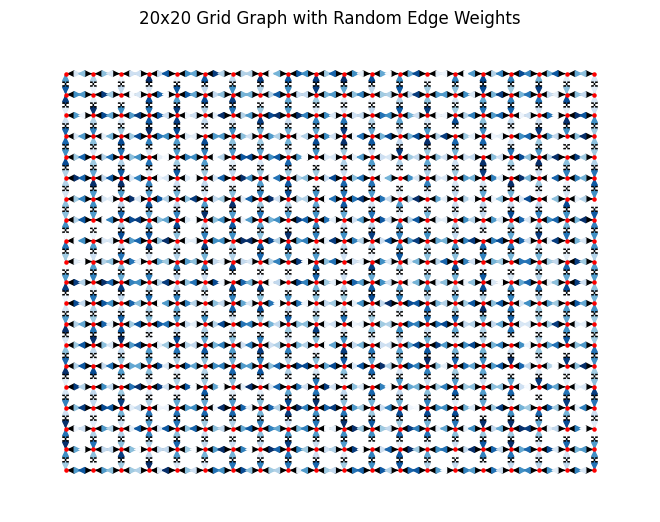

In [92]:
# set up a 20 x 20 grid graph
G: nx.Graph = nx.grid_2d_graph(20, 20, create_using=nx.DiGraph)

# assign random weights to the edges
for u, v in G.edges():
    G.edges[u, v]["weight"] = random.randint(1, 20)

# visualize the graph
pos = {(x, y): (x, y) for x, y in G.nodes()}
weights = nx.get_edge_attributes(G, "weight")

nx.draw(G, pos, with_labels=False, node_size=5, node_color="red")
# color edges by weight
nx.draw_networkx_edges(
    G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Blues
)

plt.title("20x20 Grid Graph with Random Edge Weights")
plt.show()

In [93]:
from attr import dataclass
from enum import IntEnum


class SchoolType(IntEnum):
    NONE = (0,)
    ELEMENTARY = (1,)
    MIDDLE = (2,)
    HIGH = 3


@dataclass(frozen=True)
class Stop:
    name: str
    location: tuple[int, int]


@dataclass(frozen=True)
class Depot:
    name: str
    location: tuple[int, int]


@dataclass(frozen=True)
class School:
    name: str
    location: tuple[int, int]
    type: SchoolType
    start_time: int  # in minutes from midnight


@dataclass(frozen=True)
class Bus:
    id: int
    capacity: int
    range: int
    has_wheelchair_access: bool
    depot: Depot


@dataclass(frozen=True)
class Student:
    name: str
    location: tuple[int, int]
    school: School
    stop: Stop
    requires_monitor: bool
    requires_wheelchair: bool

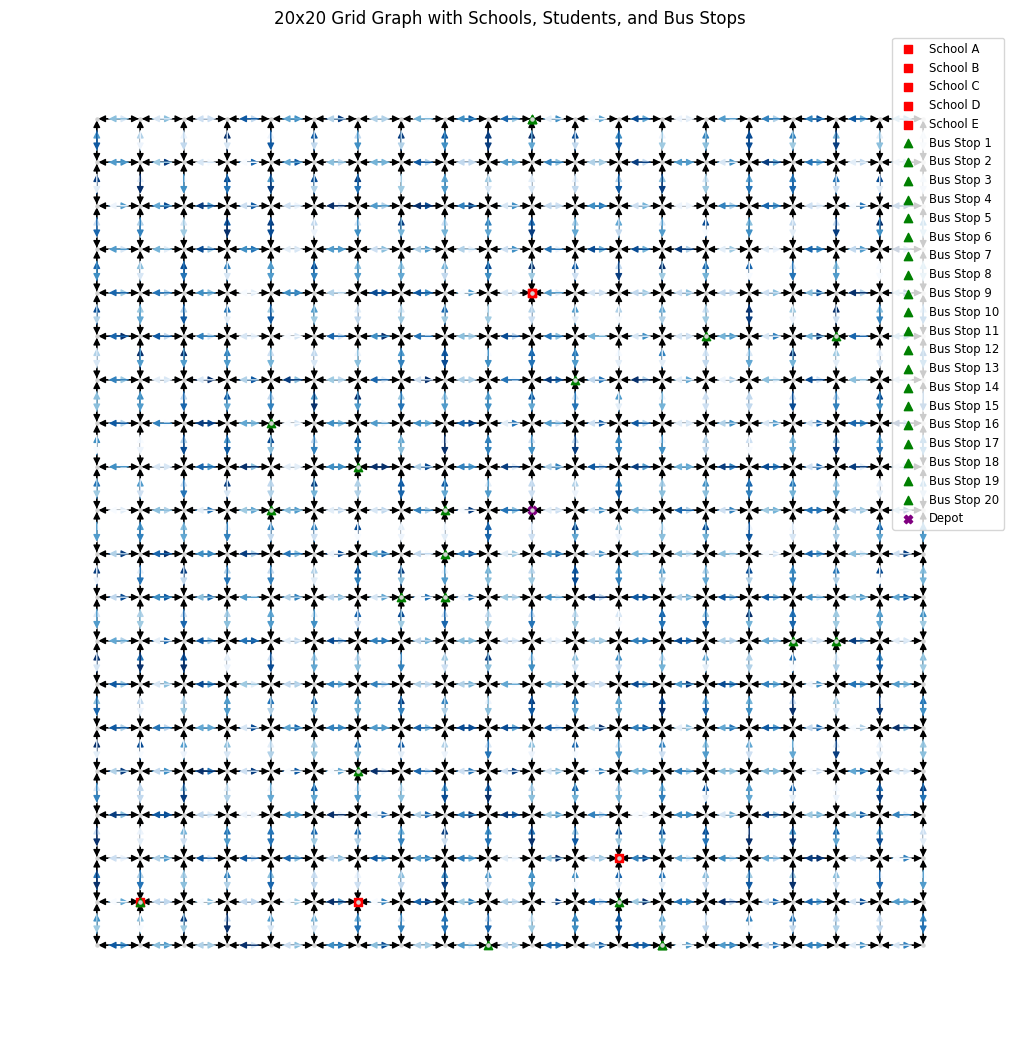

In [94]:
# add 5 schools at random positions, each either elementary, middle, or high school
school_names = ["School A", "School B", "School C", "School D", "School E"]
school_types = [SchoolType.ELEMENTARY, SchoolType.MIDDLE, SchoolType.HIGH]
schools: list[School] = []
for i in range(5):
    school = School(
        name=school_names[i],
        location=(random.randint(0, 19), random.randint(0, 19)),
        type=random.choice(school_types),
        start_time=random.randint(
            7 * 60, 9 * 60
        ),  # schools start between 7 and 9 AM in minutes from midnight
    )
    schools.append(school)

# add 20 bus stops at random positions
bus_stops: list[Stop] = []
for i in range(20):
    x = random.randint(0, 19)
    y = random.randint(0, 19)
    bus_stops.append(Stop(name=f"Bus Stop {i+1}", location=(x, y)))

# depots
depots: list[Depot] = [Depot(name="Depot", location=(10, 10))]

# visualize the graph with schools, students, and bus stops
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=False, node_size=5, node_color="lightgray")
# color edges by weight
nx.draw_networkx_edges(
    G, pos, edge_color=list(weights.values()), edge_cmap=plt.cm.Blues
)
# plot schools, students, and bus stops
for school in schools:
    plt.scatter(
        school.location[0], school.location[1], c="red", marker="s", label=school.name
    )
# for student in students:
#     plt.scatter(student.home_location[0], student.home_location[1], c='blue', marker='o', label=student.name)
for bus_stop in bus_stops:
    plt.scatter(
        bus_stop.location[0],
        bus_stop.location[1],
        c="green",
        marker="^",
        label=bus_stop.name,
    )
for depot in depots:
    plt.scatter(
        depot.location[0], depot.location[1], c="purple", marker="X", label=depot.name
    )

plt.title("20x20 Grid Graph with Schools, Students, and Bus Stops")
plt.legend(loc="upper right", fontsize="small")
plt.show()

In [95]:
buses = []
for i in range(3):
    bus = Bus(
        id=i + 1,
        capacity=8,
        range=30,
        # ensure at least one bus has wheelchair access
        has_wheelchair_access=(True if i == 0 else False),
        depot=random.choice(depots),
    )
    buses.append(bus)


def get_nearest_stop(location: tuple[int, int], stops: list[Stop]):
    min_distance = float("inf")
    nearest_stop = None
    for stop in stops:
        distance = (
            (location[0] - stop.location[0]) ** 2
            + (location[1] - stop.location[1]) ** 2
        ) ** 0.5
        if distance < min_distance:
            min_distance = distance
            nearest_stop = stop
    return nearest_stop


# add 10 students at random positions, going to random schools
student_names = [
    "Student 1",
    "Student 2",
    "Student 3",
    "Student 4",
    "Student 5",
    "Student 6",
    "Student 7",
    "Student 8",
    "Student 9",
    "Student 10",
]
students: list[Student] = []
for student_name in student_names:
    location = (random.randint(0, 19), random.randint(0, 19))
    student = Student(
        name=student_name,
        location=location,
        school=random.choice(schools),
        stop=get_nearest_stop(location, bus_stops),
        requires_monitor=random.choice(
            [True, False, False, False, False]
        ),  # some students require monitoring
        requires_wheelchair=random.choice(
            [True, False, False, False, False]
        ),  # some students require wheelchair accessibility
    )
    students.append(student)  # store the student object for later reference

In [96]:
# CONSTANTS

# boarding dwell time per student
ALPHA = 0.3

# alighting dwell time per student
BETA = 0.5

# max ride time in minutes
H_RIDE = 60

# ratio of students served
PHI = 1.0

# non-negative time separation used for precedence
EPSILON = 1e-5

# small nonnegative per-round tie-breaker penalty
LAMBDA_ROUND = 1.0

# capacity multiplier for different school types
KAPPA = {SchoolType.ELEMENTARY: 1.0, SchoolType.MIDDLE: 0.8, SchoolType.HIGH: 0.6}

# big-M for time linking
M_TIME = 1000  # could be more accurate but thats later ig

# big-M for capacity linking
M_CAPACITY = 1000  # could be more accurate but thats later ig

# big-M for school type linking
M_TYPE = SchoolType.HIGH.value + 1

In [97]:
P: list[Stop] = []  # pickup stop nodes

S: list[School] = []  # school nodes
S_PLUS: list[School] = []  # school start-copy nodes

D: list[Depot] = []  # depot nodes
D_PLUS: list[Depot] = []  # depot start-copy nodes
D_MINUS: list[Depot] = []  # depot end-copy nodes

for bus_stop in bus_stops:
    P.append(bus_stop)

for school in schools:
    S.append(school)
    school_copy = School(
        name=school.name + " (copy)",
        location=school.location,
        type=school.type,
        start_time=school.start_time,
    )
    S_PLUS.append(school_copy)

for depot in depots:
    D.append(depot)
    depot_start = Depot(name=depot.name + " (start)", location=depot.location)
    depot_end = Depot(name=depot.name + " (end)", location=depot.location)
    D_PLUS.append(depot_start)
    D_MINUS.append(depot_end)

N: list[School | Depot | Stop] = P + S + D_PLUS + D_MINUS + S_PLUS

# Directed arcs on the service graph between service nodes.
A: dict[tuple[School | Depot | Stop, School | Depot | Stop], list[tuple[int, int]]] = {}
for start_node in N:
    start_location = start_node.location
    for end_node in N:
        end_location = end_node.location
        if not A.get((start_node, end_node)):
            A[(start_node, end_node)] = nx.shortest_path(
                G, source=start_location, target=end_location, weight="weight"
            )
        if not A.get((end_node, start_node)):
            A[(end_node, start_node)] = nx.shortest_path(
                G, source=end_location, target=start_location, weight="weight"
            )

B: list[Bus] = buses

M: list[Student] = students

# students needing monitor, eg special education or wheelchair
F: list[Student] = list(
    filter(lambda s: s.requires_monitor or s.requires_wheelchair, M)
)

# students requiring wheelchair access
W: list[Student] = list(filter(lambda s: s.requires_wheelchair, F))

# rounds a bus is allowed to have
Q: list[int] = list(range(3))

# Maximum number of sequential rounds allowed per bus (handpicked).
Q_MAX = Q[-1]

In [98]:
def p_m(m: Student):
    """pickup stop of student m"""
    return m.stop


def s_m(m: Student):
    """school of student m"""
    return m.school


def tau_m(m: Student):
    """type of school of student m"""
    return m.school.type


def f_m(m: Student):
    """1 if student m if flagged"""
    return 1 if m.requires_monitor or m.requires_wheelchair else 0


def depot_b(b: Bus):
    """depot of bus b"""
    return b.depot


def C_b(b: Bus):
    """capacity of bus b"""
    return b.capacity


def Wh_b(b: Bus):
    """1 if bus b has wheelchair access"""
    return 1 if b.has_wheelchair_access else 0


def R_b(b: Bus):
    """range of bus b in miles"""
    return b.range


def t_ij(i: tuple[int, int], j: tuple[int, int]):
    """travel time from node i to node j in minutes"""
    if A.get((i, j)):
        path = A[(i, j)]
        travel_time = 0
        for k in range(len(path) - 1):
            edge_data = G.get_edge_data(path[k], path[k + 1])
            if edge_data and "weight" in edge_data:
                travel_time += edge_data["weight"]
            else:
                travel_time += 1  # default travel time if weight is missing
        return travel_time
    else:
        return float("inf")  # no path between i and j


def d_ij(i: tuple[int, int], j: tuple[int, int]):
    """shortest distance from node i to node j in miles, for now same as above"""
    return t_ij(i, j)


def h_s(s: School):
    """start time of school s in minutes from midnight"""
    return s.start_time


def slack_s(s: School):
    """required slack time for school s in minutes, same in our case"""
    return 30


def l_s(s: School):
    """latest allowable arrival time at school s in minutes from midnight"""
    return h_s(s) - slack_s(s)


def Thorizon():
    """a safe time-horizon upper bound used to bound T_bqi and set Big-M"""
    max_arrival_time = max(l_s(school) for school in schools)
    return max_arrival_time + H_RIDE + 60  # add max ride time and some buffer

In [99]:
import cvxpy

# DECISION VARIABLES

z_b = cp.Variable((len(B)), boolean=True)  # 1 if bus b is used (nonempty tour)

z_bq = cp.Variable((len(B), len(Q)), boolean=True)  # 1 if bus b is assigned to round q

sigma_bq = cp.Variable(
    (len(B), len(Q))
)  # Type of bus b in round q (elem, middle, high, etc.)

x_bqij = cp.Variable(
    (len(B), len(Q), len(A)), boolean=True
)  # 1 if bus b in round q travels from node i to node j

v_bqi = cp.Variable(
    (len(B), len(Q), len(N)), boolean=True
)  # 1 if bus b in round q visits node i

a_mbq = cp.Variable(
    (len(M), len(B), len(Q)), boolean=True
)  # 1 if student m is assigned to bus b in round q

T_bqi = cp.Variable((len(B), len(Q), len(N)))  # time bus b in round q arrives at node i

L_bqi = cp.Variable(
    (len(B), len(Q), len(N))
)  # load of bus b in round q after serving node i

e_bqs = cp.Variable(
    (len(B), len(Q), len(S)), boolean=True
)  # 1 if bus b in round q ends at school s

r_bmon = cp.Variable(
    (len(B)), boolean=True
)  # 1 if bus b as a monitor (ie serves a flagged student)

In [100]:
# COMMON USEFUL DERIVED EXPRESSIONS


def u_pu(b: Bus, q: int, p: Stop) -> cp.Expression:
    """Number boarded at pickup stop p by bus b in round q

    .. math::
        u^{\\mathrm{pu}}_{b,q,p}:=\\sum_{m:\\,p_m=p} a_{mbq}
    """
    return cp.sum(a_mbq[b, q, m] for m in students if p_m(m) == p)


def u_do(b: Bus, q: int, s: School) -> cp.Expression:
    """Number alignted at school s by from b in round q

    .. math::
        u^{\\mathrm{do}}_{b,q,s}:=\\sum_{m:\\,s_m=s} a_{mbq}
    """
    return cp.sum(a_mbq[b, q, m] for m in students if s_m(m) == s)


def svc_p(b: Bus, q: int, p: Stop) -> cp.Expression:
    """Pickup dwell time at stop p in round q

    .. math::
        \\mathrm{svc}_{b,q,p}:=\\alpha\\,u^{\\mathrm{pu}}_{b,q,p}
    """
    return ALPHA * u_pu(b, q, p)


def svc_s(b: Bus, q: int, s: School) -> cp.Expression:
    """Drop-off dwell time at school s in round q

    .. math::
        \\mathrm{svc}_{b,q,s}:=\\beta\\,u^{\\mathrm{do}}_{b,q,s}
    """
    return BETA * u_do(b, q, s)


def c_bqi(b: Bus, q: int, i: tuple[int, int]) -> cp.Expression:
    """Remaining capacity leaving node i in round q

    .. math::
        c_{b,q,i}:=C_b*\\kappa_{\\sigma_{b,q}}-L_{b,q,i}$
    """
    return (
        C_b(b) * KAPPA.get(SchoolType(int(sigma_bq[b, q].value)), 1.0) - L_bqi[b, q, i]
    )

In [ ]:
objective = cp.Minimize(
    cp.sum(
        [
            cp.sum(
                [
                    d_ij(*ij) * x_bqij[i, j, k]
                    for i in range(len(B))
                    for j in range(len(Q))
                    for k, ij in enumerate(A)
                ]
            ),
            LAMBDA_ROUND * cp.sum(z_bq),
            cp.sum(r_bmon),
        ]
    )
)

constraints: list[cvxpy.Constraint] = []

In [ ]:
# STUDENT ASSIGNMENT

# Each student is served by at most one (bus, round)
for m in range(len(M)):
    constraints.append(cp.sum(a_mbq[m, :, :]) <= 1)

# Minimum pickup / coverage requirement
constraints.append(cp.sum(a_mbq) >= PHI * len(M))

# If student assigned to (b,q), that bus-round is used
for m in range(len(M)):
    for b in range(len(B)):
        for q in range(len(Q)):
            constraints.append(a_mbq[m, b, q] <= z_bq[b, q])

# Round must carry at least one student
for b in range(len(B)):
    for q in range(len(Q)):
        constraints.append(z_bq[b, q] <= cp.sum(a_mbq[:, b, q]))

# If bus is used, it must carry at least one student (in some round)
for b in range(len(B)):
    constraints.append(z_b[b] <= cp.sum(a_mbq[:, b, :]))

In [ ]:
# ROUTING / TOUR STRUCTURE

for b, bus in enumerate(B):
    constraints.append(
        cp.sum(
            [
                x_bqij[b, Q[0], i]
                for i, path in enumerate(A.keys())
                if path[0] == depot_b(bus)
            ]
        )
        == z_bq[b, Q[0]]
    )

# round-end school selection (if next round is used, current round must end at exactly one school)
for b, bus in enumerate(B):
    for q in Q[1:]:
        constraints.append(
            cp.sum(
                [
                    x_bqij[b, Q[0], i]
                    for i, path in enumerate(A.keys())
                    if path[0] == depot_b(bus)
                ]
            )
            == 0
        )

for b in range(len(B)):
    for q in Q[:-1]:
        constraints.append(cp.sum(e_bqs[b, q, :]) == 0)

# start of each round (Q[0] starts at depot; q[1:] starts at the previous round's end school copy s^+)
for b in range(len(B)):
    for s in range(len(S)):
        # don't use school copy nodes for round 0
        constraints.append(
            cp.sum(
                [
                    x_bqij[b, Q[0], i]
                    for i, path in enumerate(A.keys())
                    if path[0] in S_PLUS
                ]
            )
            == 0
        )

In [105]:
prob = cp.Problem(objective, constraints)